<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-2/blob/main/DL08_CNN/CNN_1_convolution_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 1. Convolution 원리 이해하기

| 순서 | 내용 |
|---|---|
| 1 | 왜 MLP 말고 CNN인가? (parameter 수 비교) |
| 2 | Convolution을 손으로 계산해보기 + 사람이 만든 filter |
| 3 | Output shape 계산 퀴즈 |
| 4 | Pooling, translation equivariance, receptive field |

> 요즘은 AI 도구로 CNN 코드 자체는 금방 만듦.
> 대신 **"shape 에러가 왜 났는지", "이 구조가 내 데이터에 맞는지"** 판단하는 능력이 중요

출처: https://github.com/Harry24k/Pytorch-Basic

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)

# 이 노트북은 계산량이 작아서 CPU로도 충분함
def count_params(model):
    # 학습되는 parameter(weight + bias) 개수 합
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 1. 왜 CNN인가? — parameter 수 비교

224×224 컬러 이미지(= 150,528개 숫자)를 MLP(Linear layer)에 넣으면 첫 layer부터 parameter가 폭발함.

In [2]:
# 224x224x3 이미지를 펼쳐서 hidden 1000개 Linear에 넣는 경우
mlp_first  = nn.Linear(224 * 224 * 3, 1000)
# 같은 이미지에 3x3 filter 64개짜리 Conv2d 적용하는 경우
conv_first = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3)

print(f"Linear  첫 layer parameter 수: {count_params(mlp_first):>13,}")
print(f"Conv2d  첫 layer parameter 수: {count_params(conv_first):>13,}")

Linear  첫 layer parameter 수:   150,529,000
Conv2d  첫 layer parameter 수:         1,792


CNN이 parameter를 이렇게 아낄 수 있는 이유 = 이미지에 대한 가정들을 네트워크 구조에 넣었기 때문

1. **Locality**: 픽셀은 멀리 있는 픽셀보다 *주변* 픽셀과 관계가 큼 → 작은 filter(3×3, 5×5)만 봄
2. **Weight sharing**: "세로 edge"는 이미지 왼쪽에 있든 오른쪽에 있든 같은 패턴임 → 같은 filter를 모든 위치에 재사용

→ 가정이 데이터에 맞으면 적은 데이터로도 잘 학습됨. 반대로 **가정이 안 맞는 데이터**(예: 열 순서가 의미 없는 tabular 데이터)에 CNN 쓰면 이득 없음.

## 2. Convolution 직접 계산해보기

Convolution = filter(kernel)를 이미지 위에서 한 칸씩 밀면서, 겹치는 부분끼리 **곱하고 더하는** 연산임.

![conv](https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 540kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.12MB/s]


label: 5 | shape: (1, 1, 28, 28)


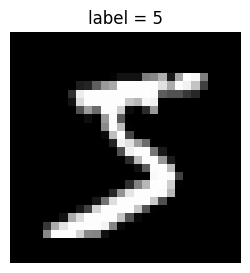

In [3]:
mnist = dsets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
img, label = mnist[0]          # img: [1, 28, 28] (channel, height, width), 값 범위 0~1
img = img.unsqueeze(0)         # conv 연산은 batch 차원 필요 → [1, 1, 28, 28]
print("label:", label, "| shape:", tuple(img.shape))

plt.figure(figsize=(3, 3))
plt.imshow(img[0, 0], cmap="gray"); plt.title(f"label = {label}"); plt.axis("off"); plt.show()

### 2-1. 손 계산 vs `F.conv2d` 결과 비교

In [4]:
# 세로 edge를 찾는 filter (Sobel filter): 왼쪽은 -, 오른쪽은 + → 좌우 밝기 차이에 반응함
k_vertical = torch.tensor([[-1., 0., 1.],
                           [-2., 0., 2.],
                           [-1., 0., 1.]])

i, j = 8, 12                                  # 임의의 위치
patch = img[0, 0, i:i+3, j:j+3]               # 이미지에서 3x3 조각 잘라냄
manual = (patch * k_vertical).sum()           # 원소별 곱 → 전부 더함 = convolution 한 칸

# PyTorch conv2d weight shape: [out_channels, in_channels, kH, kW]
out = F.conv2d(img, k_vertical.view(1, 1, 3, 3))
print("손 계산     :", round(manual.item(), 4))
print("F.conv2d 값 :", round(out[0, 0, i, j].item(), 4))
print("출력 shape  :", tuple(out.shape), "← padding 없으면 28 → 26으로 줄어듦")

손 계산     : -3.1059
F.conv2d 값 : -3.1059
출력 shape  : (1, 1, 26, 26) ← padding 없으면 28 → 26으로 줄어듦


### 2-2. 직접 설계한 filter들을 적용해보기

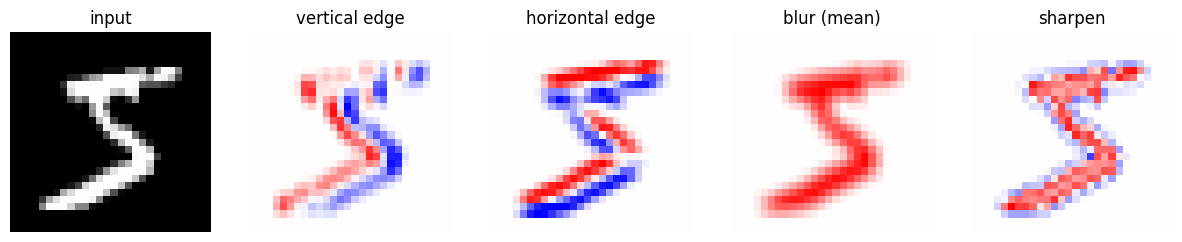

In [5]:
filters = {
    "vertical edge":   k_vertical,
    "horizontal edge": k_vertical.T,                        # 전치하면 가로 edge filter
    "blur (mean)":     torch.ones(3, 3) / 9,                # 주변 평균 → 흐리게
    "sharpen":         torch.tensor([[0., -1., 0.],
                                     [-1., 5., -1.],
                                     [0., -1., 0.]]),
}

fig, axes = plt.subplots(1, len(filters) + 1, figsize=(15, 3))
axes[0].imshow(img[0, 0], cmap="gray"); axes[0].set_title("input")
for ax, (name, k) in zip(axes[1:], filters.items()):
    fmap = F.conv2d(img, k.view(1, 1, 3, 3), padding=1)     # padding=1 → 크기 28 유지
    ax.imshow(fmap[0, 0], cmap="bwr", vmin=-fmap.abs().max(), vmax=fmap.abs().max())
    ax.set_title(name)
for ax in axes: ax.axis("off")
plt.show()

- 결과 이미지를 **feature map** 이라고 부름. 빨강(+)/파랑(-)이 진할수록 filter 패턴과 강하게 일치하는 위치임.
- CNN은 filter 값 9개(×채널×개수)를 **데이터로부터 gradient descent로 학습**함 (CNN 핵심)

## 3. Output shape 계산

- input 크기: $N$ (N×N 이미지), filter 크기: $F$, padding: $P$, stride: $S$

$$\text{output} = \left\lfloor \frac{N + 2P - F}{S} \right\rfloor + 1$$

- **padding**: 가장자리에 0을 덧대서 크기 줄어드는 걸 막음 (3×3 filter + padding 1 → 크기 유지)
- **stride**: filter를 몇 칸씩 건너뛸지 (stride 2 → 크기 약 절반)
- **MaxPool2d(2, 2)**: 2×2 영역에서 최댓값만 남김 → 크기 절반, 위 공식 그대로 적용됨 (F=2, S=2)
- **channel 수**: 크기와 무관. `out_channels` = filter 개수 = 출력 channel 수. 다음 layer의 `in_channels`와 반드시 같아야 함.

> **팁**: 공식 외우는 것보다 **dummy tensor를 넣어 layer별 shape을 출력**해보는 게 제일 빠르고 정확함.

In [6]:
def print_shapes(model, x):
    # Sequential 모델에 dummy 입력 넣고 layer별 출력 shape 출력하는 helper
    print(f"{'input':<45} {tuple(x.shape)}")
    for layer in model:
        x = layer(x)
        print(f"{str(layer):<45} {tuple(x.shape)}")

demo = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 28 → 28 (padding 1이 3x3 filter 손실 보완)
    nn.ReLU(),
    nn.MaxPool2d(2, 2),                           # 28 → 14
    nn.Conv2d(16, 32, kernel_size=3, stride=2),   # (14 - 3)//2 + 1 = 6
)
print_shapes(demo, torch.rand(1, 1, 28, 28))

input                                         (1, 1, 28, 28)
Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) (1, 16, 28, 28)
ReLU()                                        (1, 16, 28, 28)
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False) (1, 16, 14, 14)
Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2)) (1, 32, 6, 6)


### 퀴즈

In [7]:
def check(build, x_shape, y_shape):
    # build(): 모델 만드는 함수. 출력 shape이 목표와 같은지 확인함
    try:
        out = build()(torch.rand(*x_shape))
        if tuple(out.shape) == tuple(y_shape):
            print("✅ 정답!", tuple(out.shape))
        else:
            print(f"❌ 출력 {tuple(out.shape)} ≠ 목표 {tuple(y_shape)}")
    except Exception as e:
        if "ellipsis" in str(e).lower():
            print("❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행")
        else:
            print("❌ 에러:", type(e).__name__, "-", str(e)[:120])

**Q1. 28×28 → 24×24**

In [8]:
K = ...  # TODO: kernel_size
check(lambda: nn.Sequential(
    nn.Conv2d(1, 1, K),
), (100, 1, 28, 28), (100, 1, 24, 24))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`K = 5` → 28 - 5 + 1 = 24
</details>

**Q2. 28×28 → 30×30 (kernel 1)**

In [9]:
P = ...  # TODO: padding
check(lambda: nn.Sequential(
    nn.Conv2d(1, 1, 1, padding=P),
), (100, 1, 28, 28), (100, 1, 30, 30))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`P = 1` → 28 + 2·1 - 1 + 1 = 30. 1×1 filter에 padding 주면 오히려 커짐
</details>

**Q3. channel 1 → 10, 크기 28 → 22**

In [10]:
C_IN, C_OUT = ..., ...  # TODO
check(lambda: nn.Sequential(
    nn.Conv2d(1, 3, 5),
    nn.ReLU(),
    nn.Conv2d(C_IN, C_OUT, 3),
), (100, 1, 28, 28), (100, 10, 22, 22))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`C_IN, C_OUT = 3, 10` → 앞 layer out_channels(3)와 in_channels가 같아야 함. 28→24→22
</details>

**Q4. MaxPool 크기 맞추기 → (64, 8, 8)**

In [11]:
POOL = ...  # TODO: MaxPool2d(POOL, POOL)
check(lambda: nn.Sequential(
    nn.Conv2d(1, 4, 4),     # 28 → 25
    nn.ReLU(),
    nn.Conv2d(4, 32, 4),    # 25 → 22
    nn.ReLU(),
    nn.MaxPool2d(POOL, POOL),
    nn.Conv2d(32, 64, 4),
), (100, 1, 28, 28), (100, 64, 8, 8))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`POOL = 2` → 22 → 11 → 11 - 4 + 1 = 8. 거꾸로(8 → 11 → ?) 계산하면 쉬움
</details>

**Q5. padding 있는 layer 다음 kernel → (32, 26, 26)**

In [12]:
K = ...  # TODO
check(lambda: nn.Sequential(
    nn.Conv2d(1, 4, 4, padding=2),
    nn.ReLU(),
    nn.Conv2d(4, 32, K),
), (100, 1, 28, 28), (100, 32, 26, 26))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`K = 4` → 28 + 4 - 4 + 1 = 29 → 29 - 4 + 1 = 26
</details>

**Q6. stride 맞추기 → (64, 8, 8)**

In [13]:
S = ...  # TODO
check(lambda: nn.Sequential(
    nn.Conv2d(1, 4, 4),
    nn.ReLU(),
    nn.Conv2d(4, 32, 4, stride=S),
    nn.ReLU(),
    nn.Conv2d(32, 64, 4),
), (100, 1, 28, 28), (100, 64, 8, 8))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`S = 2` → 25 → ⌊(25 - 4)/2⌋ + 1 = 11 → 8
</details>

**Q7. 다음 노트북(CNN 2)의 CNN 구조 완성 → (64, 3, 3)**

In [14]:
A, B, K = ..., ..., ...  # TODO
check(lambda: nn.Sequential(
    nn.Conv2d(1, A, 5),
    nn.ReLU(),
    nn.Conv2d(16, 32, 5),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(B, 64, K),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
), (100, 1, 28, 28), (100, 64, 3, 3))

❌ 아직 안 채움: ... 를 숫자로 바꾸고 다시 실행


<details><summary>정답 보기</summary>

`A, B, K = 16, 32, 5` → 28→24→20→10→6→3. (K=4도 가능: 10→7→3, floor 때문)
</details>

### 퀴즈: parameter 수

`nn.Conv2d(16, 32, kernel_size=5)` 의 parameter 수는? 먼저 손으로 계산 후 실행해서 확인.

<details><summary>정답 보기</summary>

filter 하나 크기 = in_channels × 5 × 5 = 16 × 25 = 400, bias 1개 → 401
filter 개수 = out_channels = 32 → **401 × 32 = 12,832**
→ **입력 이미지 크기(28×28이든 1000×1000이든)와 무관** 함. 이게 weight sharing의 효과임.
</details>

In [15]:
print(count_params(nn.Conv2d(16, 32, kernel_size=5)))

12832


## 4. Pooling, translation equivariance, receptive field

### 4-1. 이미지를 옮기면 feature map도 그대로 옮겨짐 (translation equivariance)
weight sharing 덕분에 **물체가 이동하면 feature map도 같은 만큼 이동**함.
여기에 pooling을 더하면 작은 이동에는 **출력이 거의 안 변함**.

equivariance 오차: 0.0
global max pool  : 3.717647075653076 vs 3.717647075653076


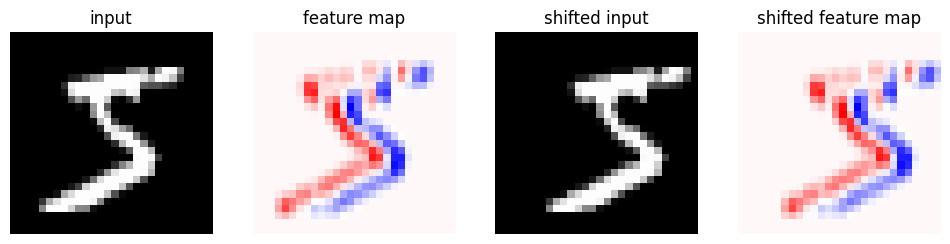

In [16]:
shift = 3
img_shift = torch.roll(img, shifts=shift, dims=-1)     # 이미지를 오른쪽으로 3픽셀 이동 (roll: 밀려난 부분은 반대편으로 넘어옴)

conv = lambda z: F.conv2d(z, k_vertical.view(1, 1, 3, 3), padding=1)
fmap, fmap_shift = conv(img), conv(img_shift)

# feature map을 똑같이 3칸 옮긴 것과 비교 → 차이 0이면 equivariance
print("equivariance 오차:", (fmap_shift - torch.roll(fmap, shift, dims=-1)).abs().max().item())
# 전체 max pooling(global max pool) 결과는 이동과 무관 → invariance
print("global max pool  :", fmap.amax().item(), "vs", fmap_shift.amax().item())

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, (t, m) in zip(axes, [("input", img), ("feature map", fmap), ("shifted input", img_shift), ("shifted feature map", fmap_shift)]):
    ax.imshow(m[0, 0], cmap="gray" if "input" in t else "bwr"); ax.set_title(t); ax.axis("off")
plt.show()

실제 CNN은 padding, stride, 경계 효과 때문에 data shift 에 생각보다 민감함.

### 4-2. Receptive field: 출력 한 칸이 입력의 어디까지 보는가?

gradient로 확인 가능함: 출력 중앙 한 픽셀을 입력으로 미분했을 때 **0이 아닌 영역 = receptive field**.

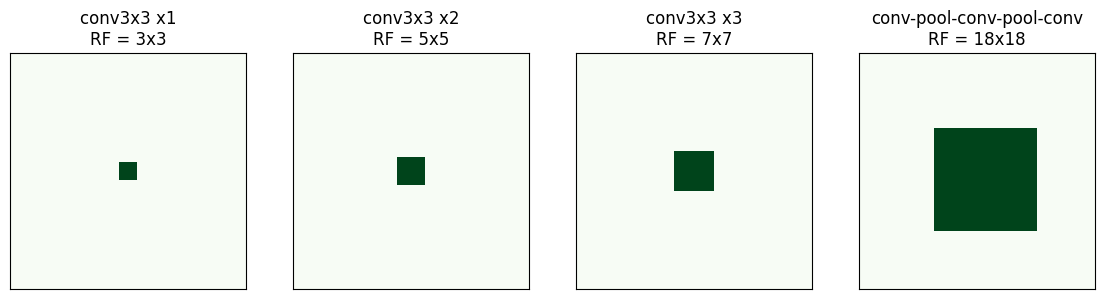

In [17]:
# 주의: MaxPool은 gradient가 최댓값 위치 하나로만 흘러서 측정이 왜곡됨 → 여기선 AvgPool로 측정함
def receptive_field(layers, size=41):
    x = torch.zeros(1, 1, size, size, requires_grad=True)
    net = nn.Sequential(*layers)
    for m in net:
        if isinstance(m, nn.Conv2d):
            nn.init.constant_(m.weight, 1.0); nn.init.zeros_(m.bias)   # 모든 weight 1로 → 영향 범위만 봄
    y = net(x)
    c = y.shape[-1] // 2
    y[0, 0, c, c].backward()                   # 출력 중앙 한 칸을 입력으로 미분
    return (x.grad[0, 0] != 0).float()

conv3 = lambda: nn.Conv2d(1, 1, 3, padding=1)
cases = {
    "conv3x3 x1":            [conv3()],
    "conv3x3 x2":            [conv3(), conv3()],
    "conv3x3 x3":            [conv3(), conv3(), conv3()],
    "conv-pool-conv-pool-conv": [conv3(), nn.AvgPool2d(2), conv3(), nn.AvgPool2d(2), conv3()],
}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (name, layers) in zip(axes, cases.items()):
    rf = receptive_field(layers)
    ax.imshow(rf, cmap="Greens"); ax.set_title(f"{name}\nRF = {int(rf.sum(0).max())}x{int(rf.sum(1).max())}")
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

- 3×3 conv를 쌓을수록 receptive field가 3 → 5 → 7 로 커짐 (5×5 conv 1개 대신 3×3 두 개를 쓰는 이유: parameter 적고 비선형성 ↑ → VGG 아이디어)
- pooling(downsampling)을 끼우면 receptive field가 **훨씬 빨리** 커짐
- 층이 깊어질수록 **edge → 모양 조각 → 물체 부분 → 물체 전체** 처럼 넓고 추상적인 패턴을 보게 됨

---
## Discussion
1. 이미지가 아닌 데이터(주가 시계열, 고객 거래 테이블, 센서 로그 등) 중 CNN의 가정(locality, weight sharing)이 맞는 것과 안 맞는 것은?
   - 시계열, 센서, 음성처럼 **순서가 있고 가까운 값끼리 관련이 큰** 데이터는 잘 맞음. 열 순서를 바꿔도 의미가 같은 tabular 데이터(나이, 소득, 거래액 등)는 "주변"이라는 개념이 없어서 안 맞음.
2. 5×5 filter 하나 대신 3×3 filter 두 층을 쌓으면 뭐가 좋을까?
   - receptive field는 5×5로 같지만 parameter가 더 적고(25 vs 18, 채널 1개 기준), 층 사이에 ReLU가 들어가서 더 복잡한 패턴을 표현할 수 있음.

## Summary

| 개념 | 한 줄 요약 | 의미 |
|---|---|---|
| Convolution | 작은 filter를 밀면서 곱하고 더함 | filter 값 = 학습 대상 |
| Weight sharing | 모든 위치에 같은 filter | parameter 수가 이미지 크기와 무관 |
| Padding / Stride / Pooling | 출력 크기 조절 | shape 에러 대부분이 여기서 발생 → dummy 입력으로 확인 |
| Receptive field | 출력 한 칸이 보는 입력 범위 | 큰 물체/긴 패턴 보려면 깊게 쌓거나 downsampling |